# Homework 2 — Regression

ML Zoomcamp 2026. Goal: predict `fuel_efficiency_mpg` with linear regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Dataset

In [2]:
!wget -nc https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

File ‘car_fuel_efficiency_2026.csv’ already there; not retrieving.



### Preparing the dataset

Use only `engine_displacement`, `horsepower`, `vehicle_weight`, `model_year`, `fuel_efficiency_mpg`.

In [3]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[base]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA

Does `fuel_efficiency_mpg` have a long tail?

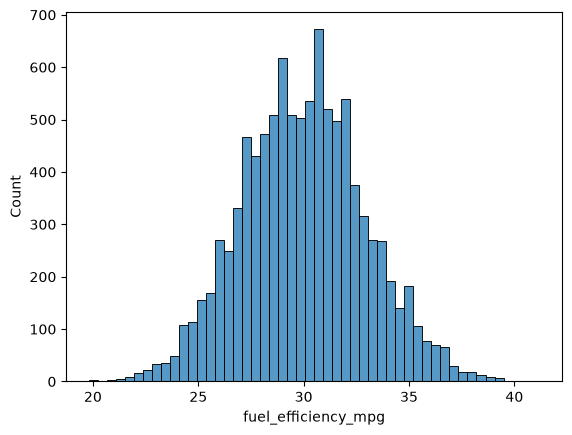

In [4]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.show()

In [5]:
df['fuel_efficiency_mpg'].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

## Question 1

Which column has missing values?

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2

Median of `horsepower`.

In [7]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train['horsepower'].median()

np.float64(254.0)

## Prepare and split the dataset

60% / 20% / 20% split, exactly as in the lecture.

In [8]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)

In [9]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

def prepare_X(df, fill_value):
    return df[features].fillna(fill_value).values

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

In [10]:
df_train, df_val, df_test = split_data(df, 42)

y_train = df_train[target].values
y_val = df_val[target].values
y_test = df_test[target].values

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Question 3

Fill missing `horsepower` with 0 vs. with the training mean; train without regularization and compare validation RMSE.

In [11]:
# Option 1: fill with 0
X_train = prepare_X(df_train, 0)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val, 0)
score_zero = round(rmse(y_val, w0 + X_val.dot(w)), 3)

# Option 2: fill with the mean (computed on train only)
mean_hp = df_train['horsepower'].mean()
X_train = prepare_X(df_train, mean_hp)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val, mean_hp)
score_mean = round(rmse(y_val, w0 + X_val.dot(w)), 3)

print('With 0:   ', score_zero)
print('With mean:', score_mean)

With 0:    2.205
With mean: 2.202


## Question 4

Regularized linear regression, NAs filled with 0.

In [12]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    score = rmse(y_val, w0 + X_val.dot(w))
    print(r, round(score, 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


## Question 5

Influence of the seed: std of validation RMSE across seeds 0–9.

In [13]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test = split_data(df, seed)
    X_train = prepare_X(df_train, 0)
    X_val = prepare_X(df_val, 0)
    w0, w = train_linear_regression(X_train, df_train[target].values)
    score = rmse(df_val[target].values, w0 + X_val.dot(w))
    scores.append(score)
    print(seed, score)

round(np.std(scores), 3)

0 2.239204143046126
1 2.2021128210838845
2 2.1634197787530947
3 2.2043588768539224
4 2.2018800943311554
5 2.2457851509085134
6 2.2697212079524043
7 2.190794599933443
8 2.216611201686444
9 2.2070365928178957


np.float64(0.029)

## Question 6

Seed 9, train on train+val, fill with 0, `r=0.001`, RMSE on test.

In [14]:
df_train, df_val, df_test = split_data(df, 9)

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
X_full_train = prepare_X(df_full_train, 0)
y_full_train = df_full_train[target].values

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test, 0)
score = rmse(df_test[target].values, w0 + X_test.dot(w))
round(score, 3)

np.float64(2.236)